# Spotify Recommender System – Part 2: Popularity Baseline
**Author:** Miguel Vásquez  
**Date:** 20 September 2025  

---

## 1. Introduction  

As a first benchmark, we implement a **popularity-based recommender system**.  
This simple heuristic recommends tracks that occur most frequently across all playlists, independent of individual user preferences.

Although this approach lacks personalization, it establishes a **lower-bound performance reference**. More advanced models (collaborative filtering, neural recommenders, hybrid approaches) will later be compared against this baseline to measure improvement.

---

## 2. Objectives of this notebook  

1. **Load preprocessed data** from the subset created in Part 1.
2. **Compute global popularity** of tracks based on frequency.
3. **Generate Top-K recommendations** using the popularity ranking.
4. **Evaluate performance** with ranking-aware metrics:
    - Precision@K
    - Recall@K
    - Hit Rate

---

## 3. Data Preparation
### 3.1 Load dataset

In [1]:
import pandas as pd
import os
from IPython.display import Markdown, display

# Ensure working directory is project root
display(Markdown(f"Current working directory: {os.getcwd()}"))
if os.getcwd() == "c:\\Users\\Miguel\\portfolio\\Spotify-Recommender-System\\notebooks":
    os.chdir("..")
    display(Markdown(f"Changed working directory to: {os.getcwd()}"))

# Load the subset of flattened tracks
tracks_df = pd.read_parquet("data/subset/tracks_subset.parquet")

# Quick overview
display(Markdown(f"Shape of dataset: {tracks_df.shape}"))
display(tracks_df.head())

Current working directory: c:\Users\Miguel\portfolio\Spotify-Recommender-System\notebooks

Changed working directory to: c:\Users\Miguel\portfolio\Spotify-Recommender-System

Shape of dataset: (9994184, 3)

,playlist_id,artist_name,track_name
0,0,Missy Elliott,Lose Control (feat. Ciara & Fat Man Scoop)
1,0,Britney Spears,Toxic
2,0,Beyoncé,Crazy In Love
3,0,Justin Timberlake,Rock Your Body
4,0,Shaggy,It Wasn't Me


### 3.2 Preprocessing

In [5]:
# Check for missing values
display(Markdown("\nMissing values per column:"))
display(tracks_df.isnull().sum())

# Check for duplicates
duplicates = tracks_df.duplicated().sum()
display(Markdown(f"\nNumber of duplicate rows: {duplicates}"))

# Drop duplicates if any
if duplicates > 0:
    tracks_df = tracks_df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed. New shape:", tracks_df.shape)

# Ensure columns are in the expected format
expected_cols = ["playlist_id", "artist_name", "track_name"]
display(Markdown("\nColumns in dataframe:"))
display(tracks_df.columns.tolist())
assert all(col in tracks_df.columns for col in expected_cols), "❌ Missing expected columns!"
display(Markdown("✅ Dataset ready for popularity model"))



Missing values per column:

playlist_id    0
artist_name    0
track_name     0
dtype: int64


Number of duplicate rows: 0


Columns in dataframe:

['playlist_id', 'artist_name', 'track_name']

✅ Dataset ready for popularity model

## 4. Popularity Model
### 4.1 Global track popularity

,track_name,artist_name,count
275455,HUMBLE.,Kendrick Lamar,6740
509243,One Dance,Drake,6312
97395,Broccoli (feat. Lil Yachty),DRAM,6095
129583,Closer,The Chainsmokers,5992
139618,Congratulations,Post Malone,5936
113356,Caroline,Aminé,5262
823794,iSpy (feat. Lil Yachty),KYLE,5183
411850,Location,Khalid,5148
61161,Bad and Boujee (feat. Lil Uzi Vert),Migos,5117
805898,XO TOUR Llif3,Lil Uzi Vert,5051


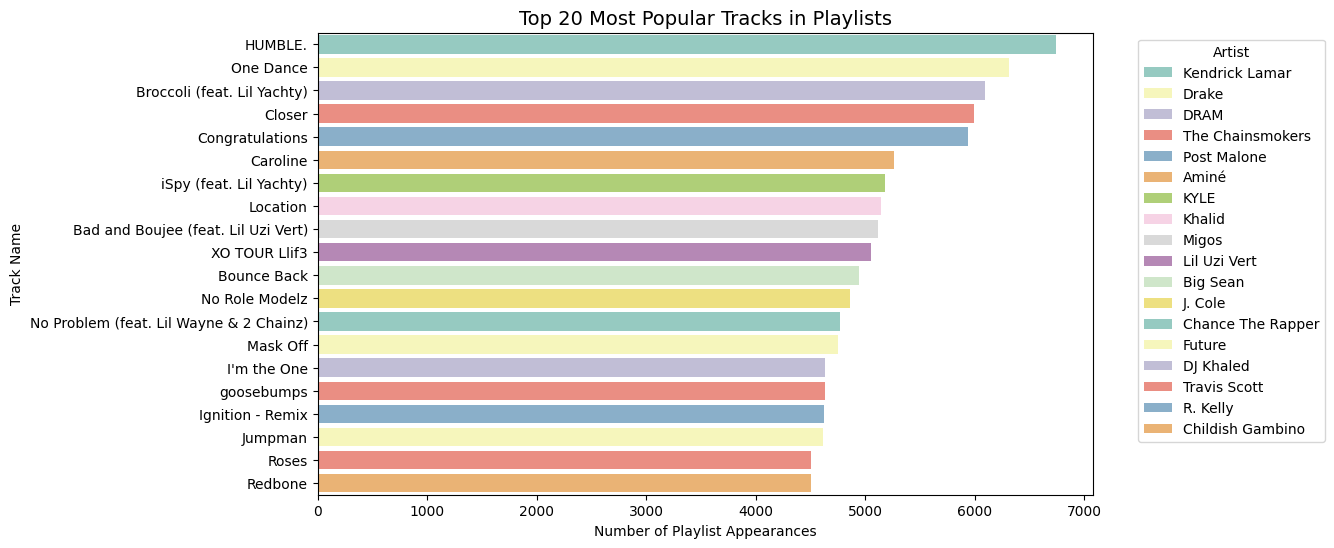

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count frequency of each track across playlists
track_popularity = (
    tracks_df.groupby(["track_name", "artist_name"])
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
)

# Display top 10
display(track_popularity.head(10))

# Plot top 20 most popular tracks
top20_tracks = track_popularity.head(20)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top20_tracks,
    x="count",
    y="track_name",
    hue="artist_name",
    dodge=False,
    palette="Set3"
)
plt.title("Top 20 Most Popular Tracks in Playlists", fontsize=14)
plt.xlabel("Number of Playlist Appearances")
plt.ylabel("Track Name")
plt.legend(title="Artist", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()



### 4.2 Recommendation strategy

In [8]:
# It always returns the top-K most popular tracks from the dataset.
def recommend_popularity(track_popularity, k=10):
    return track_popularity.head(k)[["track_name", "artist_name", "count"]]

top10_recs = recommend_popularity(track_popularity, k=10)
display(Markdown("### Example: Top-10 Popularity-Based Recommendations"))
display(top10_recs)

### Example: Top-10 Popularity-Based Recommendations

,track_name,artist_name,count
275455,HUMBLE.,Kendrick Lamar,6740
509243,One Dance,Drake,6312
97395,Broccoli (feat. Lil Yachty),DRAM,6095
129583,Closer,The Chainsmokers,5992
139618,Congratulations,Post Malone,5936
113356,Caroline,Aminé,5262
823794,iSpy (feat. Lil Yachty),KYLE,5183
411850,Location,Khalid,5148
61161,Bad and Boujee (feat. Lil Uzi Vert),Migos,5117
805898,XO TOUR Llif3,Lil Uzi Vert,5051


## 5. Evaluation
### 5.1 Train-test split

In [13]:
from sklearn.model_selection import train_test_split

# split by playlist_id: sample playlist rows into train/test
playlist_ids = tracks_df['playlist_id'].unique()
train_pids, test_pids = train_test_split(playlist_ids, test_size=0.2, random_state=42)

train_df = tracks_df[tracks_df['playlist_id'].isin(train_pids)].reset_index(drop=True)
test_df  = tracks_df[tracks_df['playlist_id'].isin(test_pids)].reset_index(drop=True)

display(Markdown(f"Unique playlists in train: {train_df['playlist_id'].nunique()}"))
display(Markdown(f"Unique playlists in test : {test_df['playlist_id'].nunique()}"))

# Recompute popularity on TRAIN (group by track+artist)
track_popularity_train = (
    train_df.groupby(['track_name', 'artist_name'])
    .size()
    .reset_index(name='count')
    .sort_values(by='count', ascending=False)
)

# Build a *list of tuples* as the ordered global recommendation list (use tuples because they are hashable)
global_recs_all = [tuple(x) for x in track_popularity_train[['track_name','artist_name']].values]

# Helper: popularity-based recommender returns list of tuples
def recommend_popularity_from_list(global_recs_list, k=10):
    return global_recs_list[:k]

Unique playlists in train: 120000

Unique playlists in test : 30000

### 5.2 Metrics

In [15]:
def precision_at_k(recommended, actual, k):
    if k == 0:
        return 0.0
    rec_k = recommended[:k]
    actual_set = set(actual)
    return len(set(rec_k) & actual_set) / k

def recall_at_k(recommended, actual, k):
    actual_set = set(actual)
    if len(actual_set) == 0:
        return 0.0
    rec_k = recommended[:k]
    return len(set(rec_k) & actual_set) / len(actual_set)

def hit_rate_at_k(recommended, actual, k):
    rec_k = set(recommended[:k])
    return 1.0 if rec_k & set(actual) else 0.0

# Evaluation loop (per playlist in test)
ks = [5, 10, 20]
results = {k: {'precision': [], 'recall': [], 'hit_rate': []} for k in ks}

# iterate by playlist in TEST
for pid, group in test_df.groupby('playlist_id'):
    # actual items in the playlist (as tuples), drop duplicates
    actual = [tuple(x) for x in group[['track_name','artist_name']].drop_duplicates().values]

    # Evaluate for different K
    for k in ks:
        recs_k = recommend_popularity_from_list(global_recs_all, k=k)
        prec = precision_at_k(recs_k, actual, k)
        rec = recall_at_k(recs_k, actual, k)
        hr  = hit_rate_at_k(recs_k, actual, k)

        results[k]['precision'].append(prec)
        results[k]['recall'].append(rec)
        results[k]['hit_rate'].append(hr)

### 5.3 Results

In [16]:
import numpy as np

summary = []
for k in ks:
    summary.append({
        'K': k,
        'Precision@K': np.mean(results[k]['precision']),
        'Recall@K': np.mean(results[k]['recall']),
        'HitRate@K': np.mean(results[k]['hit_rate'])
    })

metrics_df = pd.DataFrame(summary)
display(metrics_df)

,K,Precision@K,Recall@K,HitRate@K
0,5,0.041813,0.003520,0.137000
1,10,0.038350,0.006593,0.175933
2,20,0.034678,0.011541,0.246433


## 6. Discussion

The popularity-based baseline provides a simple yet important reference point.
Its main advantages are:
- **Simplicity**: easy to implement and computationally efficient.
- **Interpretability**: directly reflects global listening trends.
- **Scalability**: can generate recommendations instantly.  
However, its limitations are evident:
- **Lack of personalization**: all users receive the same recommendations.
- **Bias toward mainstream content**: niche or long-tail tracks are ignored.
- **Poor performance on evaluation metrics**: our results showed low Precision@K and Recall@K values, indicating that recommending the “most popular” songs alone is not sufficient for meaningful personalization.

This confirms the expectation that playlist continuation and music recommendation require more sophisticated models capable of capturing user–item interactions.

---

## 7. Next Steps

Building on this baseline, the next phase of the project will involve:
1. **Collaborative Filtering with LightFM**: leveraging both matrix factorization and content-based features.
2. **Evaluation against the baseline**: directly comparing Precision@K, Recall@K, and HitRate to measure improvements.
3. **Exploring hybrid approaches**: combining popularity, collaborative, and potentially deep learning–based methods.
4. **Scalability considerations**: ensuring that methods can handle millions of playlists efficiently.  

By progressing step by step, we move from a **naïve global heuristic** to models that better reflect the complexity of user listening behavior.